# Test Decoder: Rotated Surface Code Memory Experiment

Memory experiment of rotated surface code with pymatching decoder.
LER vs PER (Physical Error Rate) for distances d = 3, 5, 7.

In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.plot import plot_ler_vs_p

In [2]:
# Parameters: short PER list and low max_errors for fast simulation
DISTANCES = [3, 5, 7]
PER_LIST = [1e-3, 2e-3, 5e-3, 1e-2]
MAX_ERRORS = 25
NUM_WORKERS = 5  # Single-thread for notebooks (multiprocessing can be tricky)

In [3]:
# Build tasks: for each (d, p) create a stim circuit and metadata
tasks = []
for d in DISTANCES:
    for p in PER_LIST:
        # Create rotated surface code and system
        surface_code = ToricCode(distance = d) # Rotated Surface Code
        system = QECSystem()
        system.add_patch(surface_code, name="rotated")
        
        # Noise params with uniform p for all error types
        noise_params = NoiseConfig(
            p_idle=p, p_meas=p, p_reset=p,
            p_1q=p, p_2q=p
        )
        
        # Build memory experiment circuit (suppress print)
        import io
        import contextlib
        with contextlib.redirect_stdout(io.StringIO()):
            mem_exp = MemoryExperiment(
                qec_system=system,
                extraction_block_class=ToricCodeExtractionBlock,
                rounds=d,
                noise_params=noise_params,
                noise_model='circuit_level',
                basis='Z',
            )
            circuit = mem_exp.build()
        
        tasks.append(ExperimentTask(circuit, json_metadata={"d": d, "p": p}))

print(f"Built {len(tasks)} tasks")

Built 12 tasks


In [3]:
# Run simulation with pymatching decoder
decoder_config = DecoderConfig("pymatching", backend="cpu")
pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=NUM_WORKERS,
    print_progress=True,
)

df = pipeline.run_batch(tasks)
df

NameError: name 'MAX_ERRORS' is not defined

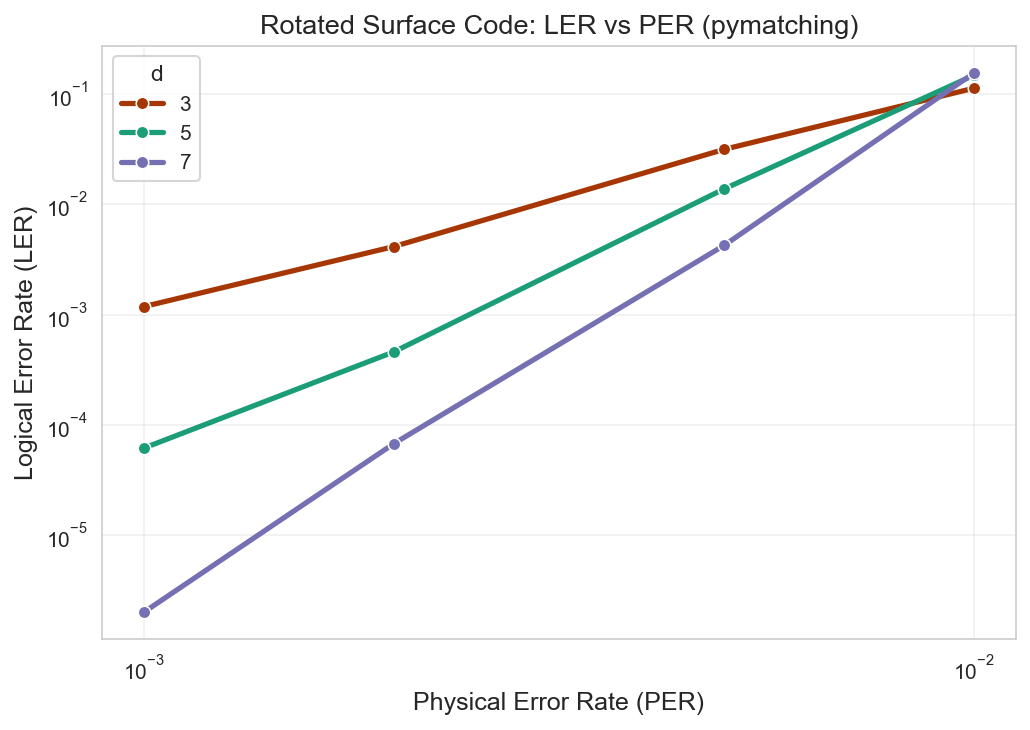

In [5]:
# Plot LER vs PER using our plot module
# Trailing ; suppresses duplicate display (plt.show already shows; Jupyter also displays returned fig)
plot_ler_vs_p(
    df,
    hue="d",
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="Rotated Surface Code: LER vs PER (pymatching)"
);

## BB Code Memory Experiment

Memory experiment on BB (Bivariate Bicycle) code with l=6, m=6, A=[[3,0],[0,1],[0,2]], B=[[0,3],[1,0],[2,0]] using **bposd** decoder.
Requires: `pip install stimbposd` (or `pip install ldpc` as fallback).

In [3]:
# BB code parameters
BB_L, BB_M = 6, 6
BB_A = [[3, 0], [0, 1], [0, 2]]
BB_B = [[0, 3], [1, 0], [2, 0]]
BB_ROUNDS = 6  # rounds for memory experiment
BB_PER_LIST = [1e-3]  # BB codes are larger; use lower PER for reasonable LER
BB_MAX_ERRORS = 25

In [4]:
# Build BB code tasks
from src.qec_code.BB_code import BBCode, BBCodeExtractionBlock

bb_tasks = []
for p in BB_PER_LIST:
    bb_code = BBCode(l=BB_L, m=BB_M, A=BB_A, B=BB_B, d=6)
    system = QECSystem()
    system.add_patch(bb_code, name="bb")
    noise_params = NoiseConfig(p_idle=p, p_meas=p, p_reset=p, p_1q=p, p_2q=p)
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        mem_exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=BBCodeExtractionBlock,
            rounds=BB_ROUNDS,
            noise_params=noise_params,
            noise_model='circuit_level',
            basis='Z',
        )
        circuit = mem_exp.build()
    bb_tasks.append(ExperimentTask(circuit, json_metadata={"p": p}))

print(f"Built {len(bb_tasks)} BB code tasks")

Built 1 BB code tasks


In [3]:
# Run simulation with bposd decoder (requires: pip install stimbposd)
decoder_config = DecoderConfig("mwpf", backend="cpu")
bb_pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=BB_MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=8,
    print_progress=True,
)

df_bb = bb_pipeline.run_batch(bb_tasks)
df_bb

Starting 8 workers...


Task 1/1: {'p': 0.001}


1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        8    mwpf 123m     999999         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 19m     999982         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 36m     999974         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 39m     999940         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 41m     999924         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 53m     999907         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8    mwpf 64m     999890         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
 

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,p
0,104686,104686,1.0,103,0.000984,6634.798731,mwpf,0.001


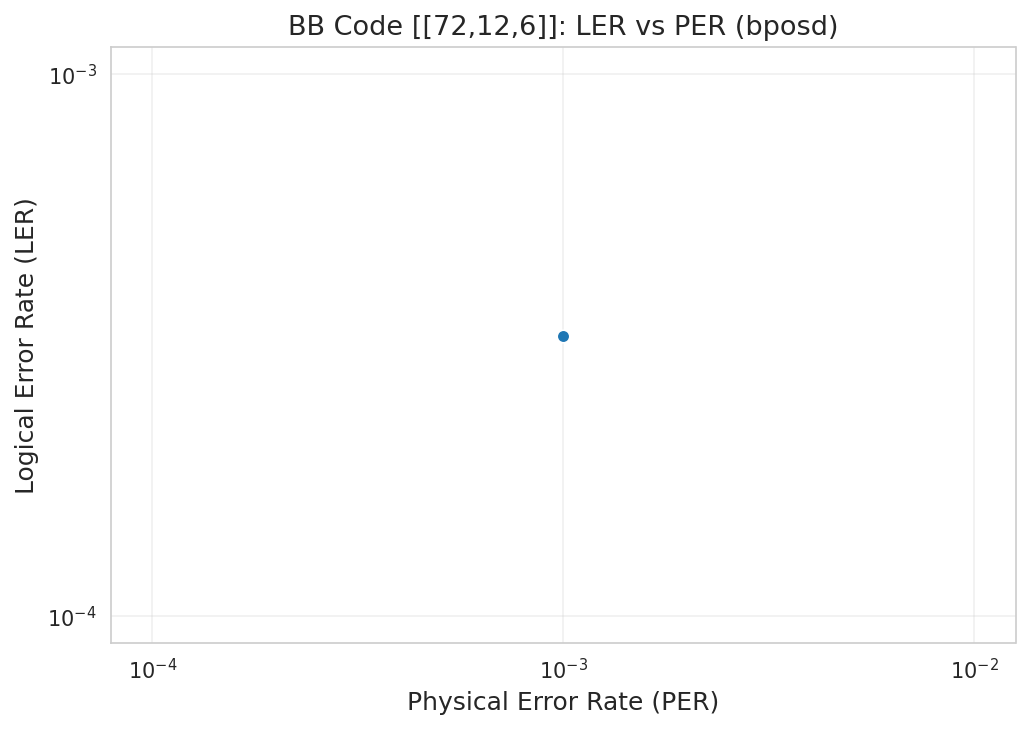

In [2]:
# Plot BB code LER vs PER (single curve; hue=None for one line)
plot_ler_vs_p(
    df_bb,
    hue=None,
    x_col="p",
    x_label="Physical Error Rate (PER)",
    y_label="Logical Error Rate (LER)",
    title="BB Code [[72,12,6]]: LER vs PER (bposd)"
);

In [2]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.plot import plot_ler_vs_p
# BB code parameters
BB_L, BB_M = 6, 6
BB_A = [[3, 0], [0, 1], [0, 2]]
BB_B = [[0, 3], [1, 0], [2, 0]]
BB_ROUNDS = 6  # rounds for memory experiment
BB_PER_LIST = [1e-3]  # BB codes are larger; use lower PER for reasonable LER
BB_MAX_ERRORS = 100
# Build BB code tasks
from src.qec_code.BB_code import BBCode, BBCodeExtractionBlock

bb_tasks = []
for p in BB_PER_LIST:
    bb_code = BBCode(l=BB_L, m=BB_M, A=BB_A, B=BB_B, d=6)
    system = QECSystem()
    system.add_patch(bb_code, name="bb")
    noise_params = NoiseConfig(p_idle=p, p_meas=p, p_reset=p, p_1q=p, p_2q=p)
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        mem_exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=BBCodeExtractionBlock,
            rounds=BB_ROUNDS,
            noise_params=noise_params,
            noise_model='circuit_level',
            basis='Z',
        )
        circuit = mem_exp.build()
    bb_tasks.append(ExperimentTask(circuit, json_metadata={"p": p}))
    # Run simulation with bposd decoder (requires: pip install stimbposd)
decoder_config = DecoderConfig("bposd", backend="cpu")
bb_pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=BB_MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=8,
    print_progress=True,
)

df_bb = bb_pipeline.run_batch(bb_tasks)
df_bb

Task 1/1: {'p': 0.001}


Starting 8 workers...
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        8   bposd 127m     999999         100 p=0.001      
1 tasks left:
  workers decoder  eta shots_left errors_left json_metadata
        8   bposd 101m     999996         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8   bposd 96m     999987         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8   bposd 53m     999936         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8   bposd 56m     999919         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8   bposd 53m     999871         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left errors_left json_metadata
        8   bposd 56m     999854         100 p=0.001      
1 tasks left:
  workers decoder eta shots_left err

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,p
0,375654,375654,1.0,109,0.00029,9335.530726,bposd,0.001


In [1]:
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from experiments.memory import MemoryExperiment
from src.qec_code.surface_code.rotated import RotatedSurfaceCode, RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.toric import ToricCode, ToricCodeExtractionBlock
from src.ir.qec_system import QECSystem
from src.noise.config import NoiseConfig
from src.simulation.decoder_backend import SimulationPipeline, ExperimentTask, DecoderConfig
from src.plot import plot_ler_vs_p
# BB code parameters
BB_L, BB_M = 6, 6
BB_A = [[3, 0], [0, 1], [0, 2]]
BB_B = [[0, 3], [1, 0], [2, 0]]
BB_ROUNDS = 6  # rounds for memory experiment
BB_PER_LIST = [1e-3]  # BB codes are larger; use lower PER for reasonable LER
BB_MAX_ERRORS = 100
# Build BB code tasks
from src.qec_code.BB_code import BBCode, BBCodeExtractionBlock

bb_tasks = []
for p in BB_PER_LIST:
    bb_code = BBCode(l=BB_L, m=BB_M, A=BB_A, B=BB_B, d=6)
    system = QECSystem()
    system.add_patch(bb_code, name="bb")
    noise_params = NoiseConfig(p_idle=p, p_meas=p, p_reset=p, p_1q=p, p_2q=p)
    import io, contextlib
    with contextlib.redirect_stdout(io.StringIO()):
        mem_exp = MemoryExperiment(
            qec_system=system,
            extraction_block_class=BBCodeExtractionBlock,
            rounds=BB_ROUNDS,
            noise_params=noise_params,
            noise_model='circuit_level',
            basis='Z',
        )
        circuit = mem_exp.build()
    bb_tasks.append(ExperimentTask(circuit, json_metadata={"p": p}))

print(f"Built {len(bb_tasks)} BB code tasks")
# Run simulation with bposd decoder (requires: pip install stimbposd)
decoder_config = DecoderConfig("bposd", backend="gpu")
bb_pipeline = SimulationPipeline(
    decoder_config=decoder_config,
    max_errors=BB_MAX_ERRORS,
    max_shots=1_000_000,
    num_workers=1, # no need for multiprocessing with GPU decoder
    print_progress=True,
)

df_bb = bb_pipeline.run_batch(bb_tasks)
df_bb
# TIP: This is raw result. Need to divide by rounds to get per-round LER

Built 1 BB code tasks
Task 1/1: {'p': 0.001}
shots=10,000 kept=10,000 errors=3 LER=3.00e-04 22.9s
shots=20,000 kept=20,000 errors=6 LER=3.00e-04 41.8s
shots=30,000 kept=30,000 errors=8 LER=2.67e-04 61.2s
shots=40,000 kept=40,000 errors=11 LER=2.75e-04 80.5s
shots=50,000 kept=50,000 errors=13 LER=2.60e-04 100.2s
shots=60,000 kept=60,000 errors=17 LER=2.83e-04 118.8s
shots=70,000 kept=70,000 errors=21 LER=3.00e-04 137.6s
shots=80,000 kept=80,000 errors=24 LER=3.00e-04 156.8s
shots=90,000 kept=90,000 errors=28 LER=3.11e-04 175.6s
shots=100,000 kept=100,000 errors=32 LER=3.20e-04 195.0s
shots=110,000 kept=110,000 errors=33 LER=3.00e-04 214.9s
shots=120,000 kept=120,000 errors=37 LER=3.08e-04 234.3s
shots=130,000 kept=130,000 errors=39 LER=3.00e-04 253.8s
shots=140,000 kept=140,000 errors=41 LER=2.93e-04 273.3s
shots=150,000 kept=150,000 errors=42 LER=2.80e-04 292.1s
shots=160,000 kept=160,000 errors=44 LER=2.75e-04 312.4s
shots=170,000 kept=170,000 errors=49 LER=2.88e-04 331.8s
shots=180,0

,shots,post_selected_shots,post_selection_rate,errors,logical_error_rate,seconds,decoder,p
0,310000,310000,1.0,102,0.000329,607.213012,bposd,0.001
